Using device: cpu


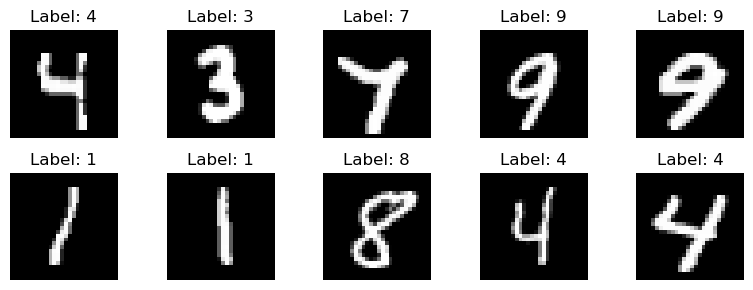

In [1]:
# Feedforward Neural Network on MNIST using PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# --------------------------------------------------
# 1. Set device
# --------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# --------------------------------------------------
# 2. Load MNIST dataset
# --------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


# --------------------------------------------------
# 3. Visualize sample images
# --------------------------------------------------

images, labels = next(iter(train_loader))

plt.figure(figsize=(8, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()



In [2]:

# --------------------------------------------------
# 4. Define Feedforward Neural Network
# --------------------------------------------------

class FeedForwardNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)


model = FeedForwardNN().to(device)
print(model)


FeedForwardNN(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [3]:


# --------------------------------------------------
# 5. Define loss function and optimizer
# --------------------------------------------------

loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# --------------------------------------------------
# 6. Train the model
# --------------------------------------------------

num_epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = loss_function(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    train_losses.append(average_loss)
    train_accuracies.append(accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Loss: {average_loss:.4f} | "
        f"Training Accuracy: {accuracy:.2f}%"
    )


Epoch 1/5 | Loss: 0.3434 | Training Accuracy: 89.65%
Epoch 2/5 | Loss: 0.1544 | Training Accuracy: 95.22%
Epoch 3/5 | Loss: 0.1160 | Training Accuracy: 96.42%
Epoch 4/5 | Loss: 0.0937 | Training Accuracy: 97.04%
Epoch 5/5 | Loss: 0.0795 | Training Accuracy: 97.46%



Test Accuracy: 96.54%


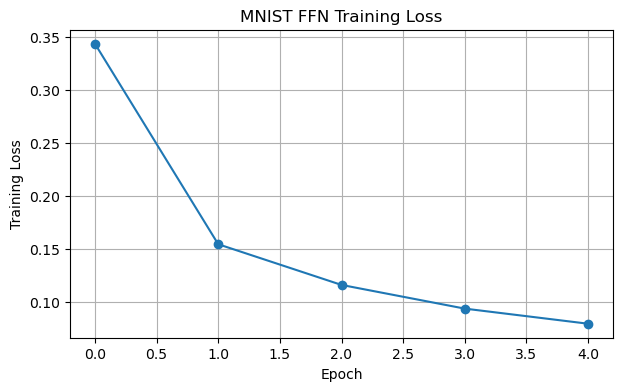

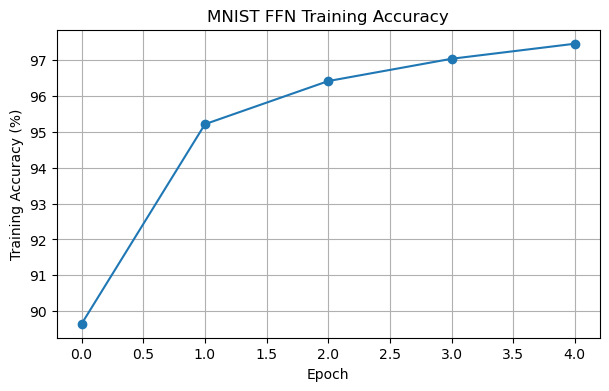

In [4]:


# --------------------------------------------------
# 7. Evaluate the model
# --------------------------------------------------

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100 * correct / total

print(f"\nTest Accuracy: {test_accuracy:.2f}%")


# --------------------------------------------------
# 8. Plot training loss
# --------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MNIST FFN Training Loss")
plt.grid(True)
plt.show()


# --------------------------------------------------
# 9. Plot training accuracy
# --------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("MNIST FFN Training Accuracy")
plt.grid(True)
plt.show()


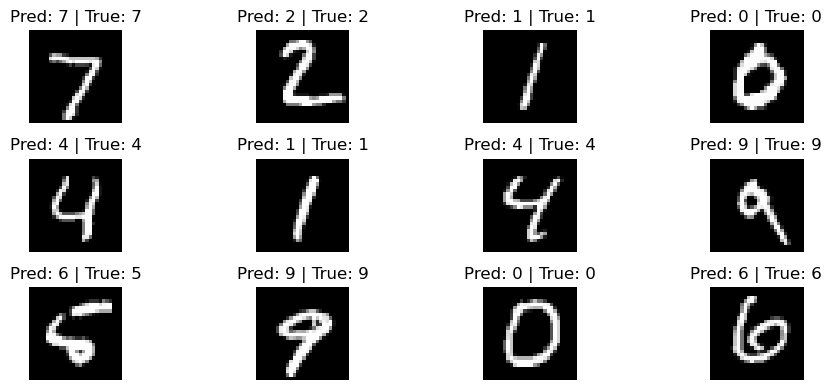

In [5]:


# --------------------------------------------------
# 10. Visualize predictions
# --------------------------------------------------

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images)
    predictions = torch.argmax(outputs, dim=1)

plt.figure(figsize=(10, 4))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap="gray")
    plt.title(
        f"Pred: {predictions[i].item()} | True: {labels[i].item()}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()